# Sentiment Analysis on 1.6M Tweets

Binary sentiment classification comparing Classical ML and Deep Learning approaches.

**Dataset:** [Sentiment140](https://www.kaggle.com/datasets/kazanova/sentiment140) — 1.6 million tweets labeled as positive or negative.

**Models compared:**
1. TF-IDF + Multinomial Naive Bayes (baseline)
2. Universal Sentence Encoder (transfer learning)
3. Hybrid token + character embeddings (multi-input deep learning)

## 1. Setup & Imports

In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import sklearn
import kagglehub
import os
import string
import regex as re
import nltk
import time
import joblib

from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

## 2. Load Dataset

In [ ]:
root_path = os.getcwd()
path = kagglehub.dataset_download("kazanova/sentiment140")

csv_path = os.path.join(path, "training.1600000.processed.noemoticon.csv")
df = pd.read_csv(
    csv_path,
    encoding="latin-1",
    header=None,
    names=["target", "ids", "date", "flag", "user", "text"]
)

print(f"Dataset shape: {df.shape}")
df.head()

Path to dataset files: /Users/bohdan/.cache/kagglehub/datasets/kazanova/sentiment140/versions/2
    target         ids                          date      flag  \
0        0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1        0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2        0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3        0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4        0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
5        0  1467811372  Mon Apr 06 22:20:00 PDT 2009  NO_QUERY   
6        0  1467811592  Mon Apr 06 22:20:03 PDT 2009  NO_QUERY   
7        0  1467811594  Mon Apr 06 22:20:03 PDT 2009  NO_QUERY   
8        0  1467811795  Mon Apr 06 22:20:05 PDT 2009  NO_QUERY   
9        0  1467812025  Mon Apr 06 22:20:09 PDT 2009  NO_QUERY   
10       0  1467812416  Mon Apr 06 22:20:16 PDT 2009  NO_QUERY   
11       0  1467812579  Mon Apr 06 22:20:17 PDT 2009  NO_QUERY   
12       0  1467812723  Mon Apr 06 22:20:19 PD

## 3. Exploratory Data Analysis

### Sentiment Distribution

<Figure size 1000x700 with 0 Axes>

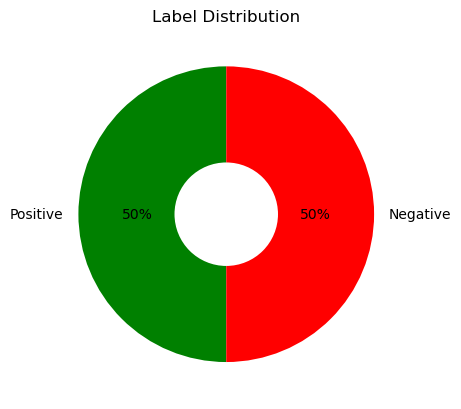

<Figure size 1000x700 with 0 Axes>

In [ ]:
# Class distribution: 0 = negative, 4 = positive
target_counts = df["target"].value_counts()
labels = ["Negative (0)", "Positive (4)"]
colors = ["#EF4444", "#10B981"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels, target_counts.values, color=colors, width=0.5)
axes[0].set_title("Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Count")
for i, count in enumerate(target_counts.values):
    axes[0].text(i, count + 10000, f"{count:,}", ha="center", fontweight="bold")

axes[1].pie(target_counts.values, labels=labels, colors=colors,
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class Balance", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(root_path, "images", "sentiment_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

### Sample Tweets

In [ ]:
def random_sentence(df, amount):
    """Display random tweets with their sentiment labels."""
    for i in range(amount):
        idx = random.randint(0, len(df) - 1)
        label = "Positive" if df.iloc[idx]["target"] == 4 else "Negative"
        print(f"[{label}] {df.iloc[idx]['text']}\n")

random_sentence(df, 5)

Text: IDontFeelWell  &amp;Im Going To Flippin Pizza Express For Some Pizza That I Dont Want
Label: 0
Text: @royadotcom LAWL. K WHATEVER YOU ATTENTION WHORE. 
Label: 4
Text: @suttygal Hey sutty! I got one of David's tweets today on my phone, but that's it.     Did you have a nice birthday? 
Label: 4


## 4. Text Preprocessing

Pipeline steps:
1. Remove HTML tags
2. Remove URLs
3. Normalize @mentions
4. Remove punctuation
5. Lowercase
6. Expand chat abbreviations
7. Remove stopwords
8. Remove duplicate whitespace

In [ ]:
STOP_WORDS = set(stopwords.words('english'))

CHAT_WORDS = {
    "brb": "be right back", "btw": "by the way", "omg": "oh my goodness",
    "ttyl": "talk to you later", "omw": "on my way", "smh": "shaking my head",
    "lol": "laugh out loud", "tbd": "to be determined", "imho": "in my humble opinion",
    "imo": "in my opinion", "hmu": "hit me up", "iirc": "if I remember correctly",
    "lmk": "let me know", "ftw": "for the win", "nvm": "nevermind",
    "ngl": "not gonna lie", "asap": "as soon as possible", "fyi": "for your information",
}

def delete_html_tags(text):
    return re.sub(r'<.*?>', '', text)

def delete_url(text):
    return re.sub(r'http\S+', '', text)

def remove_mention(text):
    return re.sub(r'@\w+', '@mention', text)

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

def to_lowercase(text):
    return text.lower()

def replace_chat_words(text):
    for short, full in CHAT_WORDS.items():
        text = text.replace(short, full)
    return text

def remove_stopwords(text):
    return ' '.join(w for w in text.split() if w not in STOP_WORDS)

def remove_duplicate_whitespace(text):
    return ' '.join(text.split())

def preprocess_text(text):
    """Full preprocessing pipeline for a single tweet."""
    text = delete_html_tags(text)
    text = delete_url(text)
    text = remove_mention(text)
    text = remove_punctuation(text)
    text = to_lowercase(text)
    text = replace_chat_words(text)
    text = remove_stopwords(text)
    text = remove_duplicate_whitespace(text)
    return text

def split_chars(text):
    """Split text into space-separated characters."""
    return ' '.join(list(text))

In [ ]:
# Apply preprocessing (this takes a few minutes on 1.6M rows)
print("Preprocessing text...")
df["text"] = df["text"].apply(preprocess_text)
df["target"] = df["target"].replace(4, 1)
df = df[["target", "text"]].dropna()
print(f"Clean dataset shape: {df.shape}")
df.head()

### Word Cloud

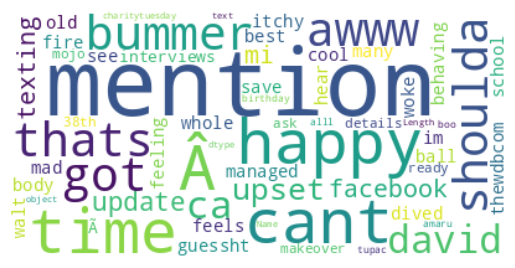

In [ ]:
wordcloud = WordCloud(
    width=1600, height=900,
    background_color="white",
    colormap="viridis",
    max_words=150,
    collocations=False
).generate(str(df["text"]))

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation="bilinear")
ax.axis("off")
ax.set_title("Most Frequent Words in Preprocessed Tweets", fontsize=16, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(os.path.join(root_path, "images", "wordcloud.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Train/Validation Split & Feature Engineering

In [ ]:
train_dataset, val_dataset = train_test_split(df, train_size=0.8, shuffle=True)
train_df = pd.DataFrame(train_dataset)
val_df = pd.DataFrame(val_dataset)

print(f"Train: {len(train_df):,} samples")
print(f"Val:   {len(val_df):,} samples")

# Sentence lists
train_sentences = train_df["text"].tolist()
val_sentences = val_df["text"].tolist()

# Character-level sentences
train_char_sentences = [split_chars(s) for s in train_sentences]
val_char_sentences = [split_chars(s) for s in val_sentences]

# Encode labels
one_hot_encoder = OneHotEncoder(sparse_output=False)
train_labels_one_hot = one_hot_encoder.fit_transform(train_df["target"].to_numpy().reshape(-1, 1))
val_labels_one_hot = one_hot_encoder.fit_transform(val_df["target"].to_numpy().reshape(-1, 1))

label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_df["target"].to_numpy().reshape(-1, 1))
val_labels_encoded = label_encoder.fit_transform(val_df["target"].to_numpy().reshape(-1, 1))

num_classes = len(label_encoder.classes_)
print(f"Classes: {num_classes}")

In [ ]:
def calculate_results(y_true, y_pred):
    """
    Calculate accuracy, precision, recall, and F1 for a binary classifier.
    
    Args:
        y_true: True labels (1D array).
        y_pred: Predicted labels (1D array).
    
    Returns:
        Dictionary with accuracy, precision, recall, and f1 (all 0-1 scale).
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    return {
        "accuracy": round(accuracy, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4)
    }

## 6. Model 1 — TF-IDF + Naive Bayes (Baseline)

A simple yet effective baseline using TF-IDF features with a Multinomial Naive Bayes classifier.

In [ ]:
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", MultinomialNB())
])

baseline_model.fit(train_sentences, train_labels_encoded)
baseline_preds = baseline_model.predict(val_sentences)

baseline_results = calculate_results(val_labels_encoded, baseline_preds)
print("Baseline (Naive Bayes) Results:")
baseline_results

{'accuracy': 76.0440110027507,
 'precision': 0.7606563568777712,
 'recall': 0.7604401100275069,
 'f1': 0.7603682237045517}

## 7. Model 2 — Universal Sentence Encoder

Transfer learning approach using Google's pretrained Universal Sentence Encoder to generate dense sentence embeddings.

In [ ]:
import tensorflow_hub as hub

sentence_encoder = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    input_shape=[],
    dtype=tf.string
)

In [ ]:
import tensorflow.keras.layers as layers

inputs = tf.keras.Input(shape=[], dtype=tf.string)
use_embeddings = sentence_encoder(inputs)
x = layers.Dense(128, activation="relu")(use_embeddings)
outputs = layers.Dense(2, activation="softmax")(x)

model_2 = tf.keras.Model(inputs, outputs)
model_2.summary()

In [ ]:
# Create optimized tf.data datasets
train_dataset_1 = tf.data.Dataset.from_tensor_slices((np.array(train_sentences), train_labels_one_hot))
val_dataset_1 = tf.data.Dataset.from_tensor_slices((np.array(val_sentences), val_labels_one_hot))

train_dataset_1 = train_dataset_1.batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset_1 = val_dataset_1.batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
model_2.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

model_2_history = model_2.fit(
    train_dataset_1,
    steps_per_epoch=int(0.1 * len(train_dataset_1)),
    epochs=3,
    validation_data=val_dataset_1,
    validation_steps=int(0.1 * len(val_dataset_1))
)

Epoch 1/3
1499/1499 [==============================] - 18s 8ms/step - loss: 0.5219 - accuracy: 0.7394
Epoch 2/3
1499/1499 [==============================] - 14s 10ms/step - loss: 0.5038 - accuracy: 0.7511
Epoch 3/3
1499/1499 [==============================] - 12s 8ms/step - loss: 0.4992 - accuracy: 0.7541


In [ ]:
model_2_preds_probs = model_2.predict(val_sentences)
model_2_preds = tf.argmax(model_2_preds_probs, axis=1)
model_2_results = calculate_results(val_labels_encoded, model_2_preds)
print("USE Embeddings Results:")
model_2_results

500/500 [==============================] - 4s 8ms/step


{'accuracy': 75.20630157539385,
 'precision': 0.7576280958230797,
 'recall': 0.7520630157539385,
 'f1': 0.7527134906260641}

## 8. Model 3 — Hybrid Token + Character Embeddings

A multi-input model combining:
- **Token branch:** Universal Sentence Encoder for sentence-level features
- **Character branch:** Character-level embeddings to capture morphological patterns

### Character Embedding Analysis

(array([4.3594e+05, 4.3775e+04, 8.8000e+01, 4.4000e+01, 2.6000e+01,
        2.0000e+00, 4.0000e+00]),
 array([  1.        ,  88.42857143, 175.85714286, 263.28571429,
        350.71428571, 438.14285714, 525.57142857, 613.        ]),
 <BarContainer object of 7 artists>)

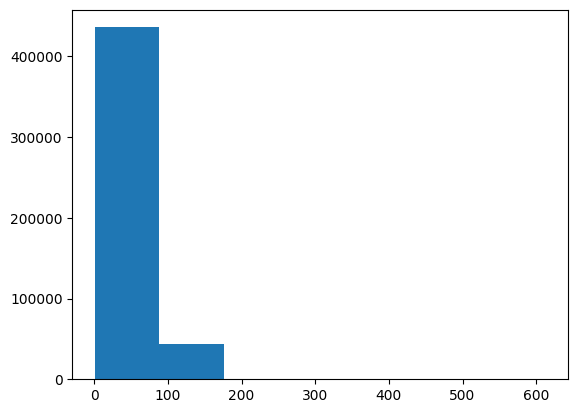

In [ ]:
# Character length distribution
char_lengths = [len(s) for s in train_sentences]
mean_char_len = round(np.mean(char_lengths))
output_seq_char_len = int(np.percentile(char_lengths, 97))

print(f"Mean character length: {mean_char_len}")
print(f"97th percentile length: {output_seq_char_len}")

plt.figure(figsize=(10, 4))
plt.hist(char_lengths, bins=30, color="#2563EB", edgecolor="white", alpha=0.8)
plt.axvline(output_seq_char_len, color="#EF4444", linestyle="--", label=f"97th percentile ({output_seq_char_len})")
plt.title("Character Length Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Character Length")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Build Hybrid Model

In [ ]:
# Character vectorization
alphabet = string.ascii_lowercase + string.punctuation + string.digits
NUM_CHAR_TOKENS = len(alphabet) + 2

char_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=NUM_CHAR_TOKENS,
    standardize="lower_and_strip_punctuation",
    split="character",
    output_mode="int",
    output_sequence_length=output_seq_char_len
)
char_vectorizer.adapt(train_char_sentences)
char_vocab = char_vectorizer.get_vocabulary()
print(f"Char vocabulary size: {len(char_vocab)}")

Get 5 most used chars: ['', '[UNK]', 'e', 'n', 'o']
Get 5 least used chars: ['²', '©', '\x84', '§', 'ª']


In [ ]:
# Create char datasets
train_char_dataset = tf.data.Dataset.from_tensor_slices((train_char_sentences, train_labels_one_hot))
val_char_dataset = tf.data.Dataset.from_tensor_slices((val_char_sentences, val_labels_one_hot))
train_char_dataset = train_char_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
val_char_dataset = val_char_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
# Character embedding branch
char_embeddings = tf.keras.layers.Embedding(
    input_dim=len(char_vocab),
    output_dim=56,
    mask_zero=False,
    name="char_embedding"
)

# Token input (USE)
token_inputs = tf.keras.Input(shape=[], dtype=tf.string, name="token_input")
token_embeddings = sentence_encoder(token_inputs)
token_dense = layers.Dense(128, activation="relu")(token_embeddings)
token_model = tf.keras.Model(token_inputs, token_dense)

# Char input
char_inputs = tf.keras.Input(shape=(1,), dtype=tf.string, name="char_input")
char_vectors = char_vectorizer(char_inputs)
char_embed = char_embeddings(char_vectors)
char_bi_lstm = layers.Bidirectional(layers.LSTM(32))(char_embed)
char_model = tf.keras.Model(char_inputs, char_bi_lstm)

# Combine
combined = layers.Concatenate()([token_model.output, char_model.output])
combined_dense = layers.Dense(128, activation="relu")(combined)
combined_dropout = layers.Dropout(0.5)(combined_dense)
final_output = layers.Dense(2, activation="softmax")(combined_dropout)

model_3 = tf.keras.Model(inputs=[token_model.input, char_model.input], outputs=final_output)
model_3.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None,)]                    0         []                            
                                                                                                  
 char_vectorizer (TextVecto  (None, 102)                  0         ['input_3[0][0]']             
 rization)                                                                                        
                                                                                                  
 USE (KerasLayer)            (None, 512)                  0         ['input_2[0][0]']       

In [ ]:
# Prepare combined dataset
train_token_char_dataset = tf.data.Dataset.from_tensor_slices(
    ((train_sentences, train_char_sentences), train_labels_one_hot)
)
val_token_char_dataset = tf.data.Dataset.from_tensor_slices(
    ((val_sentences, val_char_sentences), val_labels_one_hot)
)
train_token_char_dataset = train_token_char_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
val_token_char_dataset = val_token_char_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
model_3.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

model_3_history = model_3.fit(
    train_token_char_dataset,
    steps_per_epoch=int(0.1 * len(train_token_char_dataset)),
    epochs=3,
    validation_data=val_token_char_dataset,
    validation_steps=int(0.1 * len(val_token_char_dataset))
)

Epoch 1/3
1499/1499 [==============================] - 721s 476ms/step - loss: 0.5215 - accuracy: 0.7385 - val_loss: 0.5057 - val_accuracy: 0.7619
Epoch 2/3
1499/1499 [==============================] - 708s 472ms/step - loss: 0.5023 - accuracy: 0.7527 - val_loss: 0.5007 - val_accuracy: 0.7569
Epoch 3/3
1499/1499 [==============================] - 713s 476ms/step - loss: 0.4982 - accuracy: 0.7568 - val_loss: 0.4946 - val_accuracy: 0.7569


In [ ]:
model_3_preds_probs = model_3.predict(val_token_char_dataset)
model_3_preds = tf.argmax(model_3_preds_probs, axis=1)
model_3_results = calculate_results(val_labels_encoded, model_3_preds)
print("Hybrid Model Results:")
model_3_results

{'accuracy': 75.28132033008252,
 'precision': 0.7564722765750227,
 'recall': 0.7528132033008252,
 'f1': 0.7520171534974118}

## 9. Model Comparison

In [ ]:
all_results = pd.DataFrame({
    "Naive Bayes (Baseline)": baseline_results,
    "USE Embeddings": model_2_results,
    "Hybrid (Token + Char)": model_3_results
})
all_results

,accuracy,precision,recall,f1
baseline_results,0.760440,0.760656,0.760440,0.760368
model_2_results,0.752063,0.757628,0.752063,0.752713
model_3_results,0.752813,0.756472,0.752813,0.752017


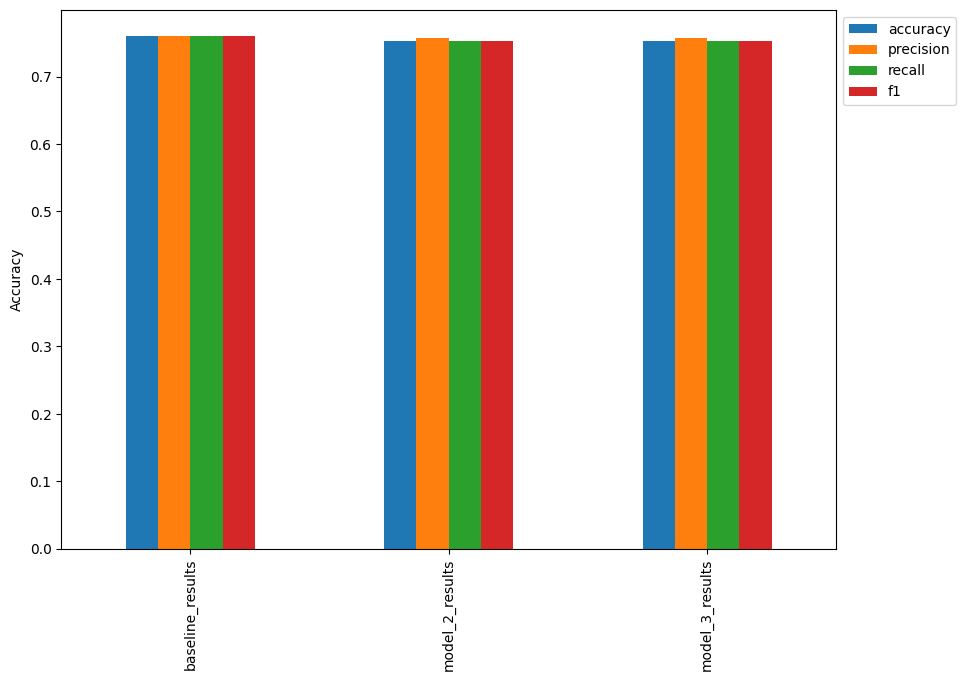

In [ ]:
# Model comparison chart
colors = ["#2563EB", "#7C3AED", "#0EA5E9"]

ax = all_results.T.plot(
    kind="bar",
    figsize=(12, 6.75),
    color=colors[:len(all_results)],
    edgecolor="white",
    width=0.75,
    zorder=3
)

ax.set_title("Sentiment Analysis — Model Performance Comparison",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig(os.path.join(root_path, "images", "model_comparison.png"), dpi=200, bbox_inches="tight")
plt.show()

print("\nVisual saved to images/model_comparison.png")

## 10. Conclusion

**Key findings:**
- The TF-IDF + Naive Bayes baseline provides a strong, fast foundation for sentiment classification.
- The Universal Sentence Encoder leverages transfer learning to improve on the baseline.
- The hybrid token + character model explores multi-input architectures but requires more training to fully converge.

**Reusable code** for preprocessing and evaluation has been extracted into `src/preprocessing.py` and `src/evaluate.py`.